# Structure Learning for MNIST with Renormalised Generative Models

Implementation of the MNIST digit classification example from:
> Friston et al. (2025) *From pixels to planning: scale-free active inference.* Front. Netw. Physiol. 5:1521963

## Preprocessing Pipeline (Section: Image compression and compositionality)

From the paper (p.10):
> MNIST images were preprocessed by up-sampling to 32 pixels x 32 pixels, smoothing, and histogram equalization. In addition, they were converted into a format suitable for video processing with three (TrueColor or RGB) channels.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu" # TODO: FIX GPU errors when running notebook

import numpy as np
from jax import numpy as jnp
import matplotlib.pyplot as plt

from preprocess import load_mnist, preprocess
from utils import extract_exemplars

In [2]:
x_train, y_train, x_test, y_test = load_mnist(cache_dir='./mnist_cache')

print(f"Training set: {x_train.shape}, labels: {y_train.shape}")
print(f"Test set:     {x_test.shape}, labels: {y_test.shape}")
print(f"Pixel range:  [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Classes:      {np.unique(np.array(y_train))}")

Training set: (60000, 28, 28), labels: (60000,)
Test set:     (10000, 28, 28), labels: (10000,)
Pixel range:  [0.0, 255.0]
Classes:      [0 1 2 3 4 5 6 7 8 9]


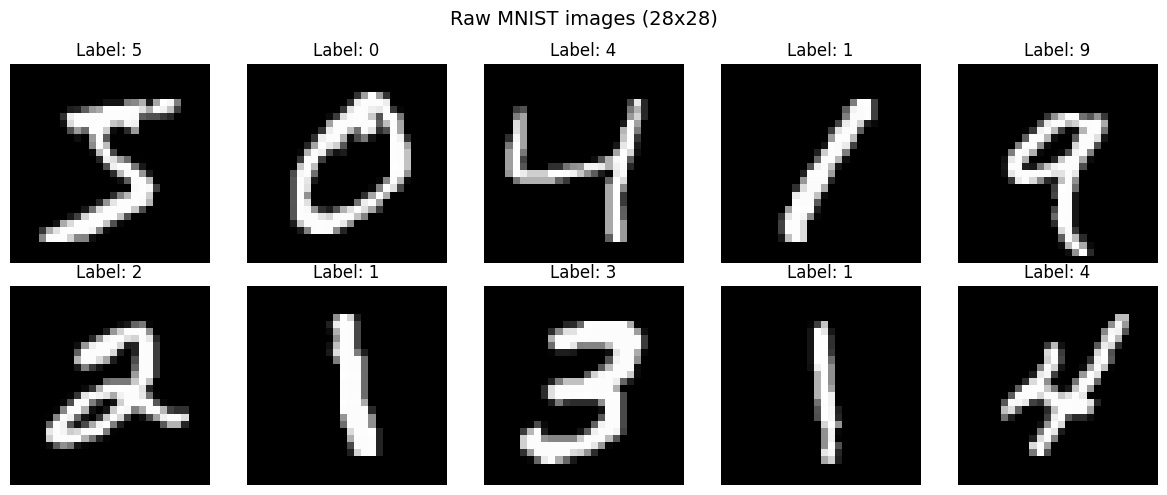

In [3]:
# Show a few raw 28x28 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
fig.suptitle('Raw MNIST images (28x28)', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Preprocess

The full pipeline applies (in order), matching SPM's `DEM_MNIST_RGM.m`:
1. **Bilinear upsampling** 28x28 → 32x32 - makes image divisible into 4x4 patches for the blocking transformation
2. **Gaussian smoothing** (FWHM=2.0, sigma≈0.85) - SPM's `spm_conv(temp,s,s)` interprets `s=2` as FWHM, converting to `sigma = FWHM / sqrt(8*log(2)) ≈ 0.85`
3. **Histogram equalization** - SPM-style rank-based Gaussian mapping to enhance contrast

Output shape: `(N, 32, 32)` grayscale

see preprocess.py for how these functions are implemented.

## 3. Select Structure Learning Exemplars

From the paper (p.10):
> Based on the prior that there can be a dozen ways of writing any given number, the first 13 (Baker's dozen) images of each digit class were used for fast structure learning.

These 130 images (13 per class x 10 classes) are used to build the initial RGM hierarchy via fast structure learning. The remaining images are used for active learning.

In [4]:
M_PER_CLASS = 13  # Baker's dozen
NUM_CLASSES = 10

x_exemplars_raw, y_exemplars, exemplar_idx = extract_exemplars(x_train, y_train, M_PER_CLASS, NUM_CLASSES)
print(f"Exemplar images: {x_exemplars_raw.shape}")
print(f"Per class: {[(y_exemplars == d).sum().item() for d in range(10)]}")

Exemplar images: (130, 28, 28)
Per class: [13, 13, 13, 13, 13, 13, 13, 13, 13, 13]


In [5]:
# Preprocess the exemplars
x_exemplars = preprocess(x_exemplars_raw)
print(f"Preprocessed exemplars: {x_exemplars.shape}")

Preprocessed exemplars: (130, 32, 32)


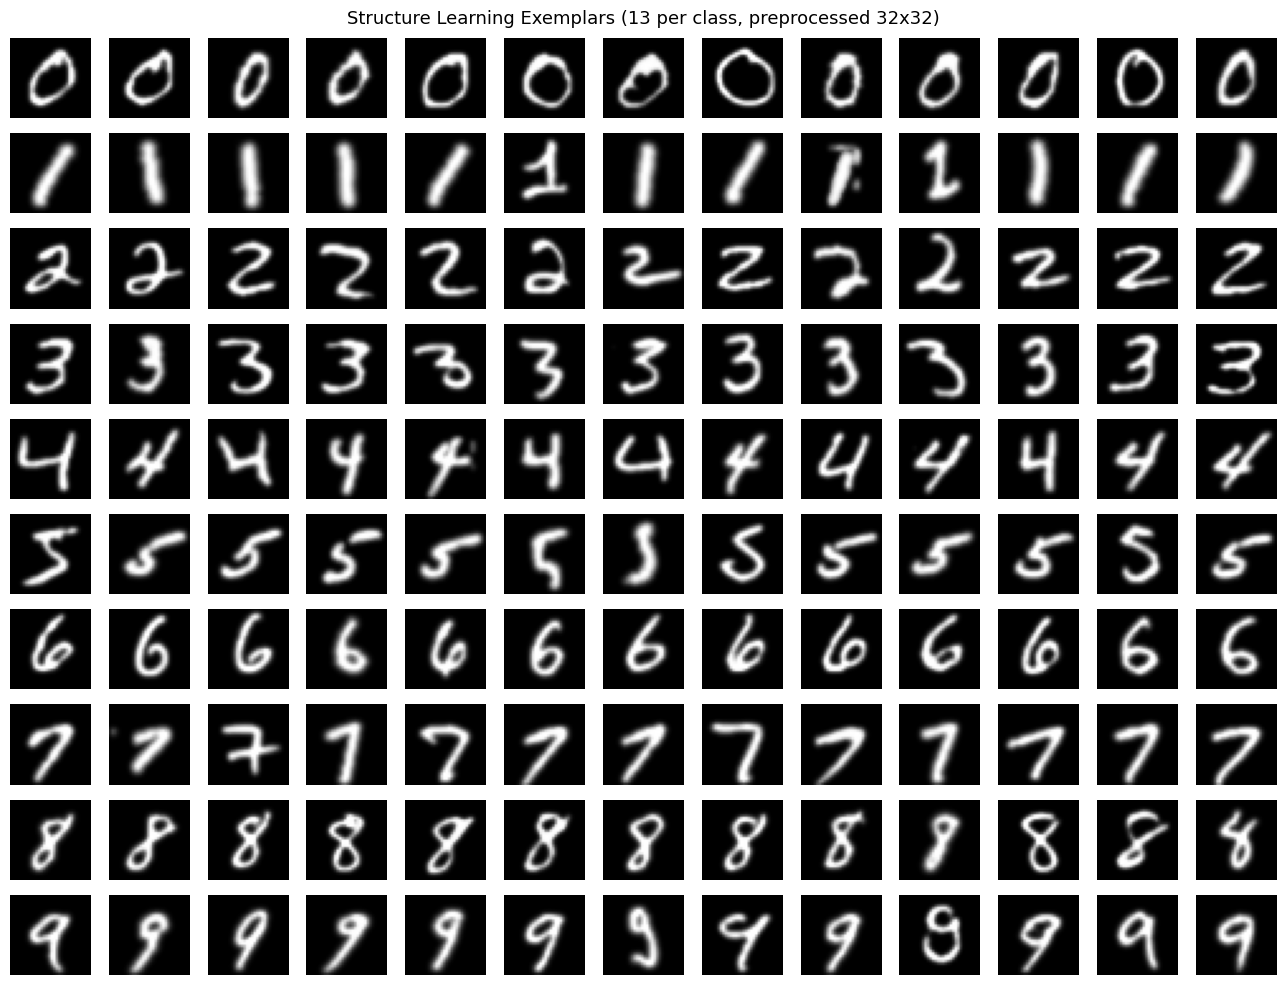

In [6]:
# Display all 130 exemplars organised by class (cf. Figure 4 in the paper)
fig, axes = plt.subplots(NUM_CLASSES, M_PER_CLASS, figsize=(M_PER_CLASS, NUM_CLASSES))
for digit in range(NUM_CLASSES):
    mask = y_exemplars == digit
    digit_imgs = x_exemplars[mask]
    for j in range(M_PER_CLASS):
        axes[digit, j].imshow(digit_imgs[j], cmap='gray')
        axes[digit, j].axis('off')
    axes[digit, 0].set_ylabel(str(digit), rotation=0, fontsize=12, labelpad=15)
fig.suptitle(f'Structure Learning Exemplars ({M_PER_CLASS} per class, preprocessed 32x32)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. SVD Discretisation

From the paper (p.8-10): Images are tessellated into 4x4 patches. Each patch location gets its own SVD basis learned from the structure exemplars. Continuous singular variates are quantised into 7 discrete levels, producing a discrete observation tensor per image. 

The main text in the paper says:

> "Each group is then subject to singular value decomposition, given a training set of images, to identify an orthogonal (spatial) basis set of singular vectors. This grouping is followed by a reduction operator that retains singular variates with large singular values (here, the first 32 principal vectors based on groups of 4 × 4 pixels)."

> "The set of singular variates for each group specifies the pattern for any given image at the corresponding location. The continuous variates can then be quantized to a discrete number of levels (here, seven)."

However the figure 4 caption says:

> "...in this example, the singular variates could take seven discrete values centered on zero for a maximum of 16 singular vectors."

And footnote 7 says:

> "In practice, we use overlapping groups, where the singular value decomposition is applied following weighting by a radial (Gaussian) basis function whose standard deviation is the distance between group centers."

**SPM alignment notes:**
- SVD modes are selected adaptively via `spm_svd(Y, 1/su)` where `su=8`, retaining only modes with normalized singular values above `1/su`. This is capped at `mm=16` max modes.
- Bin assignment uses nearest-centre (not edge-based) matching SPM's `[~, U] = min(abs(u(t,m) - a))`.
- The number of retained modes varies per patch location.

In [7]:
from discretise import (
    DiscretiseConfig,
    compute_svd_basis, encode_images, decode_observations,
    compute_svd_basis_overlapping, encode_images_overlapping, decode_observations_overlapping,
)

config = DiscretiseConfig()

# Non-overlapping (hard 4x4 partition)
basis_nol = compute_svd_basis(x_exemplars, config)
obs_nol = encode_images(x_exemplars, basis_nol)
recon_nol = decode_observations(obs_nol, basis_nol)

# Overlapping (SPM spm_tile: Gaussian-weighted, radius 2*d, sigma=d/2)
basis_ol = compute_svd_basis_overlapping(x_exemplars, config)
obs_ol = encode_images_overlapping(x_exemplars, basis_ol)
recon_ol = decode_observations_overlapping(obs_ol, basis_ol)

print("=== Non-overlapping ===")
print(f"  V shape:       {basis_nol.V.shape}")
print(f"  Modes/patch:   min={int(basis_nol.n_modes.min())}, max={int(basis_nol.n_modes.max())}, mean={float(basis_nol.n_modes.mean()):.1f}")
print(f"  MSE:           {float(((x_exemplars - recon_nol[:, 0]) ** 2).mean()):.2f}")
print()
print("=== Overlapping (SPM-style) ===")
print(f"  V shape:       {basis_ol.V.shape}")
print(f"  Modes/patch:   min={int(basis_ol.n_modes.min())}, max={int(basis_ol.n_modes.max())}, mean={float(basis_ol.n_modes.mean()):.1f}")
print(f"  MSE:           {float(((x_exemplars - recon_ol[:, 0]) ** 2).mean()):.2f}")

=== Non-overlapping ===
  V shape:       (8, 8, 16, 16)
  Modes/patch:   min=1, max=7, mean=4.3
  MSE:           223.91

=== Overlapping (SPM-style) ===
  V shape:       (8, 8, 1024, 16)
  Modes/patch:   min=3, max=9, mean=6.6
  MSE:           127.21


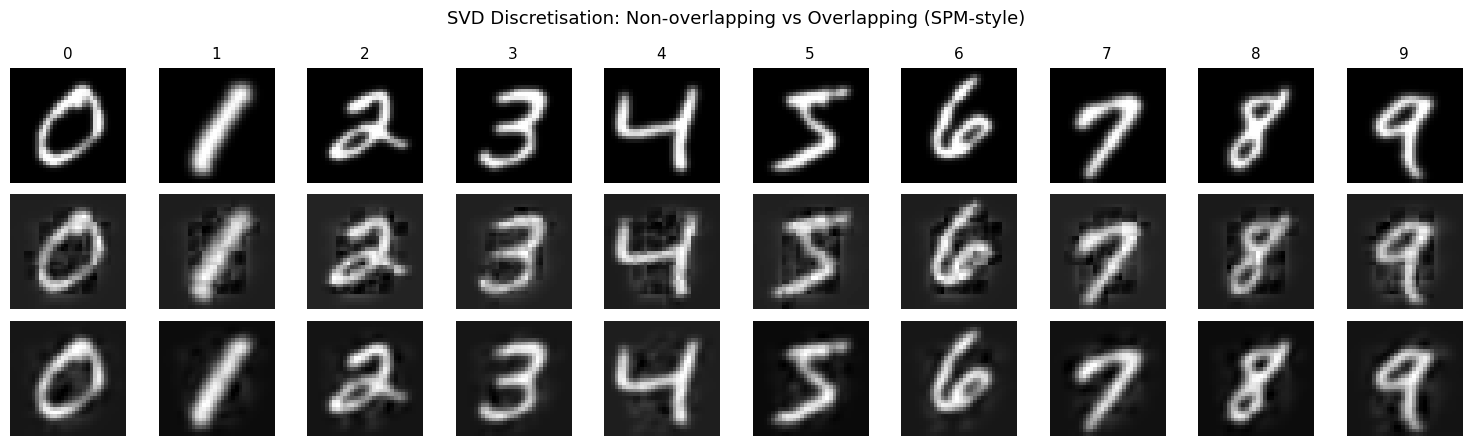

In [8]:
# Compare reconstructions: non-overlapping vs overlapping (cf. Figure 4)
show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 4.5))
for col, idx in enumerate(show_idx):
    axes[0, col].imshow(x_exemplars[idx], cmap='gray')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    axes[1, col].imshow(recon_nol[idx, 0], cmap='gray')
    axes[1, col].axis('off')
    axes[2, col].imshow(recon_ol[idx, 0], cmap='gray')
    axes[2, col].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Non-overlap', fontsize=11)
axes[2, 0].set_ylabel('Overlapping', fontsize=11)
fig.suptitle('SVD Discretisation: Non-overlapping vs Overlapping (SPM-style)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Build the RGM Hierarchy

From the paper (p.8-10): The hierarchy is built bottom-up from the structure exemplars:

1. **Level 1 (Patch states)**: Each patch location has its own set of **states** — the unique observation patterns seen across the structure exemplars. A batched pymdp Agent (one per patch) maps discrete SVD observations to these states via one-hot likelihoods.

2. **Levels 2+**: Each parent agent pools a 2×2 block of child MAP states. The unique child-state tuples observed across exemplars become the parent's state vocabulary. This halving continues until a single 1×1 grid remains — the image-level state.

The number of levels is derived automatically:
- `n_groups = image_size // group_size` → grid size at L1
- `n_levels = log2(n_groups) + 1` (here: 8×8 → 4×4 → 2×2 → 1×1 = 4 levels)

`RGMHierarchy.from_exemplars` performs all of these steps internally: SVD basis computation, patch state discovery, agent construction, and hierarchical inference at each level.

In [9]:
from hierarchy import RGMHierarchy

rgm = RGMHierarchy.from_exemplars(x_exemplars, y_exemplars, config, overlapping=True)

# Hierarchy summary
print(f"Number of levels: {len(rgm.levels)}")
for lv, level in enumerate(rgm.levels):
    grid = level.stats.num_states
    n_grid = grid.shape[0]
    print(f"  L{lv+1}: {n_grid}x{n_grid} grid, "
          f"states/location: {int(grid.min())}-{int(grid.max())} "
          f"(mean {float(grid.mean()):.1f})")

# Digit state map at the top level
n_top = int(rgm.levels[-1].stats.num_states[0, 0])
print(f"\nTop-level states: {n_top}")
print(f"Digit state map: {rgm.digit_state_map}")
n_unambiguous = (rgm.digit_state_map >= 0).sum()
print(f"Unambiguous states: {n_unambiguous}/{n_top}")
for d in range(10):
    states = [s for s in range(n_top) if rgm.digit_state_map[s] == d]
    print(f"  Digit {d}: {len(states)} states {states}")

/home/arun-niranjan/repos/pymdp/examples/renormalised_generative_models/hierarchy.py:222: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(
/home/arun-niranjan/repos/pymdp/examples/renormalised_generative_models/hierarchy.py:376: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(
/home/arun-niranjan/repos/pymdp/examples/renormalised_generative_models/hierarchy.py:376: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(


Number of levels: 4
  L1: 8x8 grid, states/location: 7-127 (mean 58.4)
  L2: 4x4 grid, states/location: 17-130 (mean 89.2)
  L3: 2x2 grid, states/location: 130-130 (mean 130.0)
  L4: 1x1 grid, states/location: 130-130 (mean 130.0)

Top-level states: 130
Digit state map: [7 7 3 5 9 3 5 0 4 4 4 2 7 7 7 2 9 8 8 6 6 0 0 0 6 8 0 2 9 9 9 4 9 8 8 0 9
 9 6 9 0 9 1 4 0 7 7 0 7 4 7 5 4 4 5 5 5 5 5 5 4 5 1 1 1 7 7 0 0 5 8 8 6 6
 8 9 8 5 3 0 4 2 9 3 5 2 8 6 6 4 3 8 6 1 1 6 1 6 6 6 2 8 2 3 2 8 0 1 3 1 1
 1 1 2 1 2 7 3 2 3 9 2 3 3 2 7 4 3 4 3]
Unambiguous states: 130/130
  Digit 0: 13 states [7, 21, 22, 23, 26, 35, 40, 44, 47, 67, 68, 79, 106]
  Digit 1: 13 states [42, 62, 63, 64, 93, 94, 96, 107, 109, 110, 111, 112, 114]
  Digit 2: 13 states [11, 15, 27, 81, 85, 100, 102, 104, 113, 115, 118, 121, 124]
  Digit 3: 13 states [2, 5, 78, 83, 90, 103, 108, 117, 119, 122, 123, 127, 129]
  Digit 4: 13 states [8, 9, 10, 31, 43, 49, 52, 53, 60, 80, 89, 126, 128]
  Digit 5: 13 states [3, 6, 51, 54, 55, 56, 57

/home/arun-niranjan/repos/pymdp/examples/renormalised_generative_models/hierarchy.py:376: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agent = Agent(


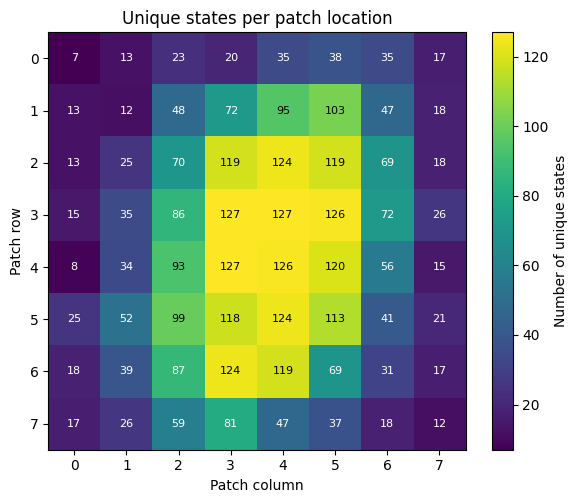

In [10]:
# Patch state count heatmap (Level 1)
l1_stats = rgm.levels[0].stats

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(l1_stats.num_states, cmap='viridis')
ax.set_title('Unique states per patch location')
ax.set_xlabel('Patch column')
ax.set_ylabel('Patch row')
for i in range(l1_stats.num_states.shape[0]):
    for j in range(l1_stats.num_states.shape[1]):
        ax.text(j, i, int(l1_stats.num_states[i, j]), ha='center', va='center',
                color='white' if l1_stats.num_states[i, j] < l1_stats.num_states.max() * 0.7 else 'black',
                fontsize=8)
fig.colorbar(im, ax=ax, label='Number of unique states')
plt.tight_layout()
plt.show()

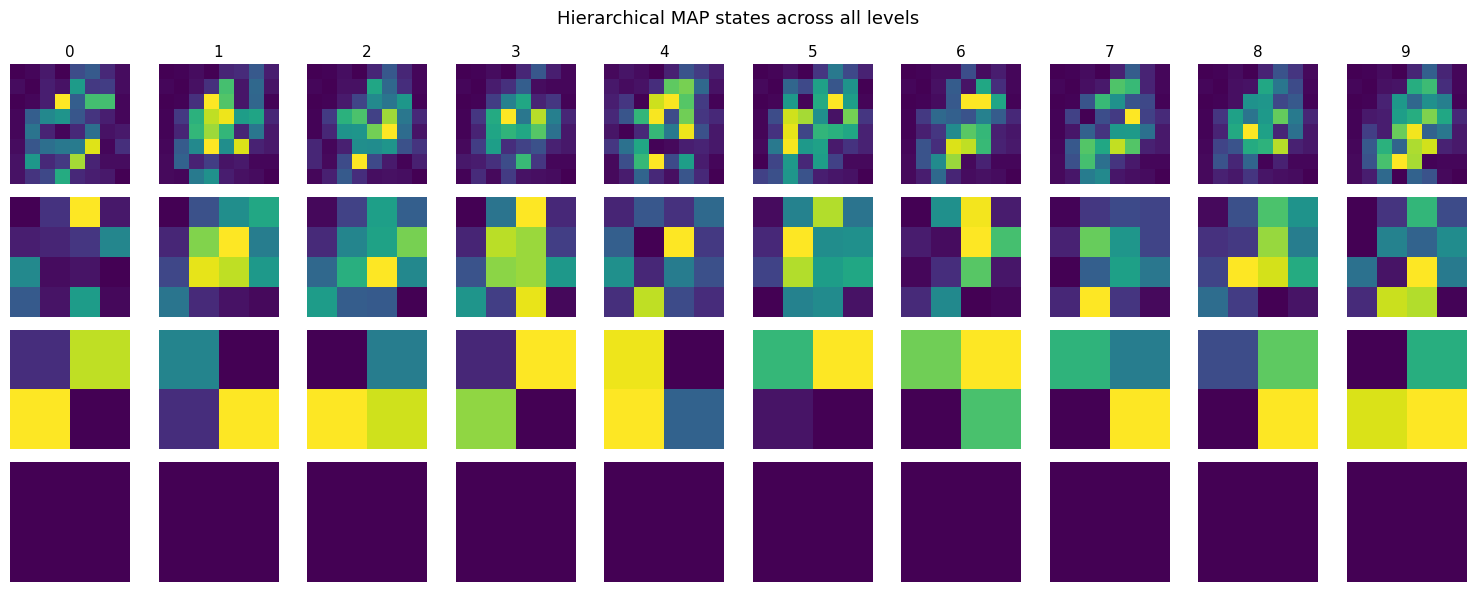

In [11]:
from hierarchy import infer_patch_states, infer_hierarchical_states
from discretise import encode_images_overlapping

# Encode exemplars and pick one image per digit
observations = encode_images_overlapping(x_exemplars, rgm.basis)
show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

n_levels = len(rgm.levels)
fig, axes = plt.subplots(n_levels, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, n_levels * 1.5))
for col, idx in enumerate(show_idx):
    # L1: patch inference
    maps = infer_patch_states(rgm.levels[0].agent, rgm.levels[0].valid_mask, observations[idx])
    axes[0, col].imshow(maps, cmap='viridis')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    # L2+: hierarchical inference
    for lv, level in enumerate(rgm.levels[1:], 1):
        maps = infer_hierarchical_states(level.agent, level.valid_mask, maps)
        axes[lv, col].imshow(maps, cmap='viridis')
        axes[lv, col].axis('off')

for lv in range(n_levels):
    grid_size = rgm.levels[lv].stats.num_states.shape[0]
    axes[lv, 0].set_ylabel(f'L{lv+1} ({grid_size}x{grid_size})', fontsize=10)
fig.suptitle('Hierarchical MAP states across all levels', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Classification and Generation

The `RGMHierarchy` object supports two key operations:
- **classify**: bottom-up inference on unseen images → digit prediction
- **generate**: top-down state lookup from digit prior → reconstructed pixel image

In [12]:
# Sanity check: classify the 130 structure exemplars (should be 100%)
pred_exemplars, l4_exemplars = rgm.classify(x_exemplars)
exemplar_acc = (pred_exemplars == np.array(y_exemplars)).mean()
print(f"Structure exemplar accuracy: {exemplar_acc:.1%} ({(pred_exemplars == np.array(y_exemplars)).sum()}/{len(y_exemplars)})")
if exemplar_acc < 1.0:
    mismatches = np.where(pred_exemplars != np.array(y_exemplars))[0]
    for idx in mismatches[:10]:
        print(f"  Image {idx}: true={y_exemplars[idx]}, pred={pred_exemplars[idx]}, L4 state={l4_exemplars[idx]}")

Structure exemplar accuracy: 100.0% (130/130)


Test accuracy (100 images): 41.0%
  Digit 0: 75.0% (6/8)
  Digit 1: 71.4% (10/14)
  Digit 2: 12.5% (1/8)
  Digit 3: 18.2% (2/11)
  Digit 4: 35.7% (5/14)
  Digit 5: 14.3% (1/7)
  Digit 6: 30.0% (3/10)
  Digit 7: 60.0% (9/15)
  Digit 8: 50.0% (1/2)
  Digit 9: 27.3% (3/11)


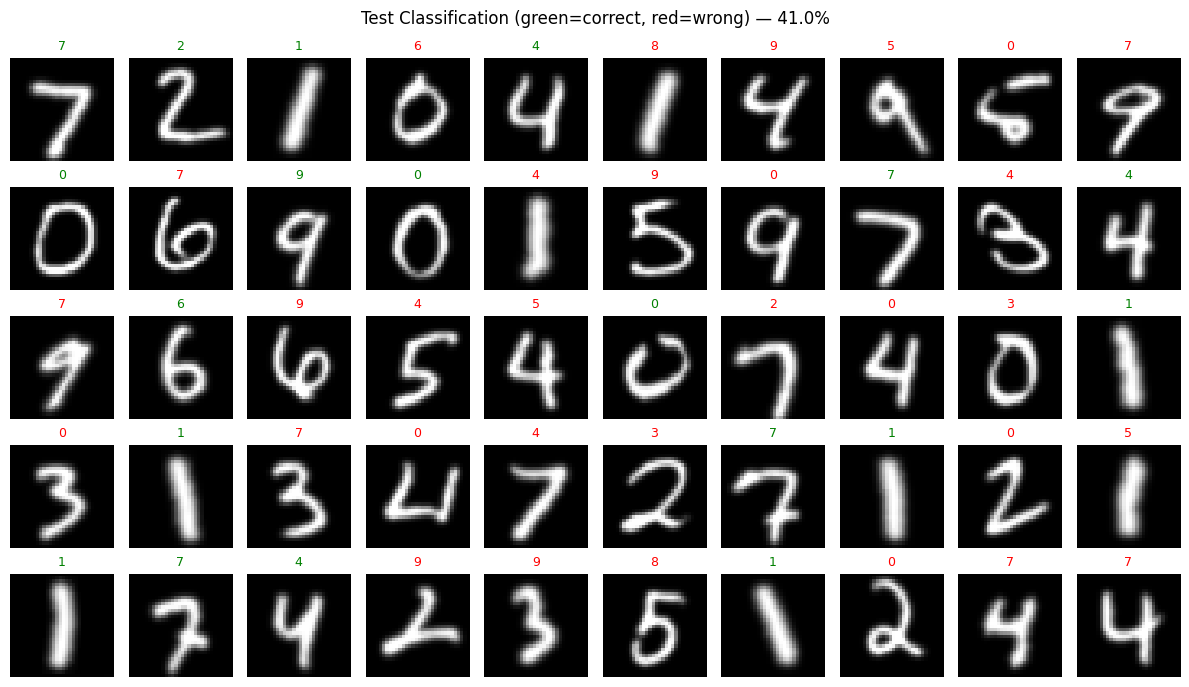

In [13]:
# Classify first 100 test images
N_TEST = 100
x_test_pre = preprocess(x_test[:N_TEST])
y_test_sub = np.array(y_test[:N_TEST])

pred_test, l4_test = rgm.classify(x_test_pre)
test_acc = (pred_test == y_test_sub).mean()
print(f"Test accuracy ({N_TEST} images): {test_acc:.1%}")

# Per-digit accuracy
for d in range(10):
    mask = y_test_sub == d
    if mask.sum() > 0:
        d_acc = (pred_test[mask] == d).mean()
        print(f"  Digit {d}: {d_acc:.1%} ({(pred_test[mask] == d).sum()}/{mask.sum()})")

# Show grid with color-coded predictions
n_show = min(50, N_TEST)
cols = 10
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.4))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(np.array(x_test_pre[i]), cmap='gray')
        correct = pred_test[i] == y_test_sub[i]
        color = 'green' if correct else 'red'
        ax.set_title(f"{pred_test[i]}", fontsize=9, color=color)
    ax.axis('off')
fig.suptitle(f'Test Classification (green=correct, red=wrong) — {test_acc:.1%}', fontsize=12)
plt.tight_layout()
plt.show()

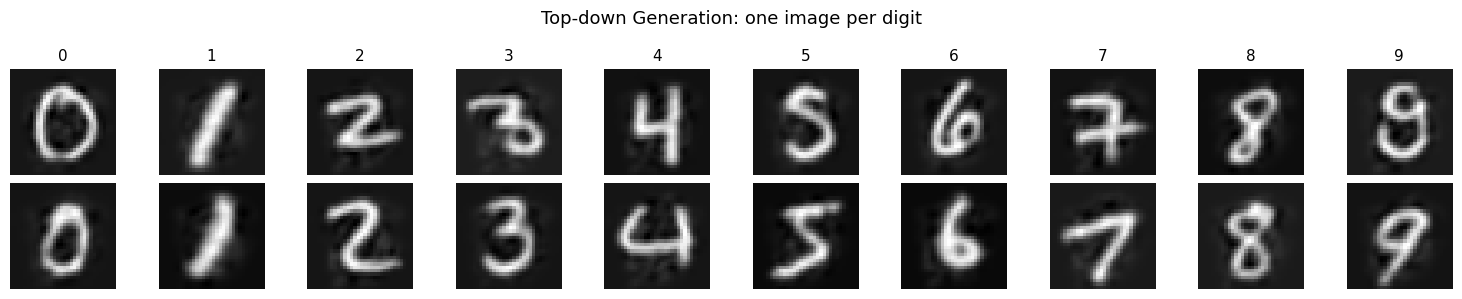

In [14]:
# Generate one image per digit: argmax (top) and sampled (bottom)
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for d in range(10):
    img_argmax, _ = rgm.generate(digit=d, sample=False)
    axes[0, d].imshow(np.array(img_argmax[0, 0]), cmap='gray')
    axes[0, d].set_title(str(d), fontsize=11)
    axes[0, d].axis('off')

    img_sample, _ = rgm.generate(digit=d, sample=True, rng=rng)
    axes[1, d].imshow(np.array(img_sample[0, 0]), cmap='gray')
    axes[1, d].axis('off')

axes[0, 0].set_ylabel('Argmax', fontsize=10)
axes[1, 0].set_ylabel('Sampled', fontsize=10)
fig.suptitle('Top-down Generation: one image per digit', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Round-trip: generate per digit -> classify back
print("Round-trip: generate -> classify")
all_match = True
for d in range(10):
    img, _ = rgm.generate(digit=d, sample=False)
    pred, l4s = rgm.classify(img)
    match = pred[0] == d
    all_match = all_match and match
    status = "OK" if match else "MISMATCH"
    print(f"  Digit {d}: generated -> classified as {pred[0]} (L4 state {l4s[0]}) [{status}]")

print(f"Round-trip {'PASSED' if all_match else 'FAILED'}: all 10 digits")

Round-trip: generate -> classify
  Digit 0: generated -> classified as 0 (L4 state 7) [OK]
  Digit 1: generated -> classified as 1 (L4 state 42) [OK]
  Digit 2: generated -> classified as 2 (L4 state 11) [OK]
  Digit 3: generated -> classified as 3 (L4 state 2) [OK]
  Digit 4: generated -> classified as 4 (L4 state 8) [OK]
  Digit 5: generated -> classified as 5 (L4 state 3) [OK]
  Digit 6: generated -> classified as 6 (L4 state 19) [OK]
  Digit 7: generated -> classified as 7 (L4 state 0) [OK]
  Digit 8: generated -> classified as 8 (L4 state 17) [OK]
  Digit 9: generated -> classified as 9 (L4 state 4) [OK]
Round-trip PASSED: all 10 digits
